========== DATASET LOADED ==========
       Location            Date_Time  Temperature_C  Humidity_pct  \
0     San Diego  2024-01-14 21:12:46      10.683001     41.195754   
1     San Diego  2024-05-17 15:22:10       8.734140     58.319107   
2     San Diego  2024-05-11 09:30:59      11.632436     38.820175   
3  Philadelphia  2024-02-26 17:32:39      -8.628976     54.074474   
4   San Antonio  2024-04-29 13:23:51      39.808213     72.899908   

   Precipitation_mm  Wind_Speed_kmh  
0          4.020119        8.233540  
1          9.111623       27.715161  
2          4.607511       28.732951  
3          3.183720       26.367303  
4          9.598282       29.898622  

Dataset Shape: (1000000, 6)

========== DATA CLEANED ==========
Remaining Rows: 1000000

========== FEATURE ENGINEERING COMPLETED ==========

Training Random Forest Model...

========== MODEL RESULTS ==========
R² Score: -0.1221
Model Score: -12.21 %
Mean Absolute Error: 13.05 °C

========== FUTURE PREDICTION ========

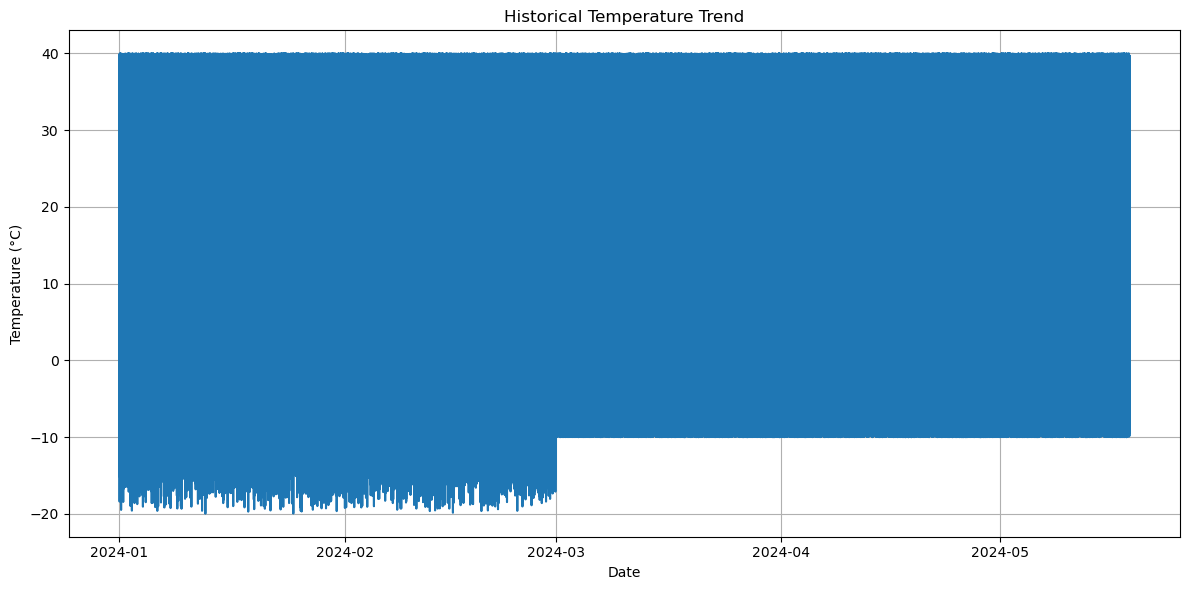

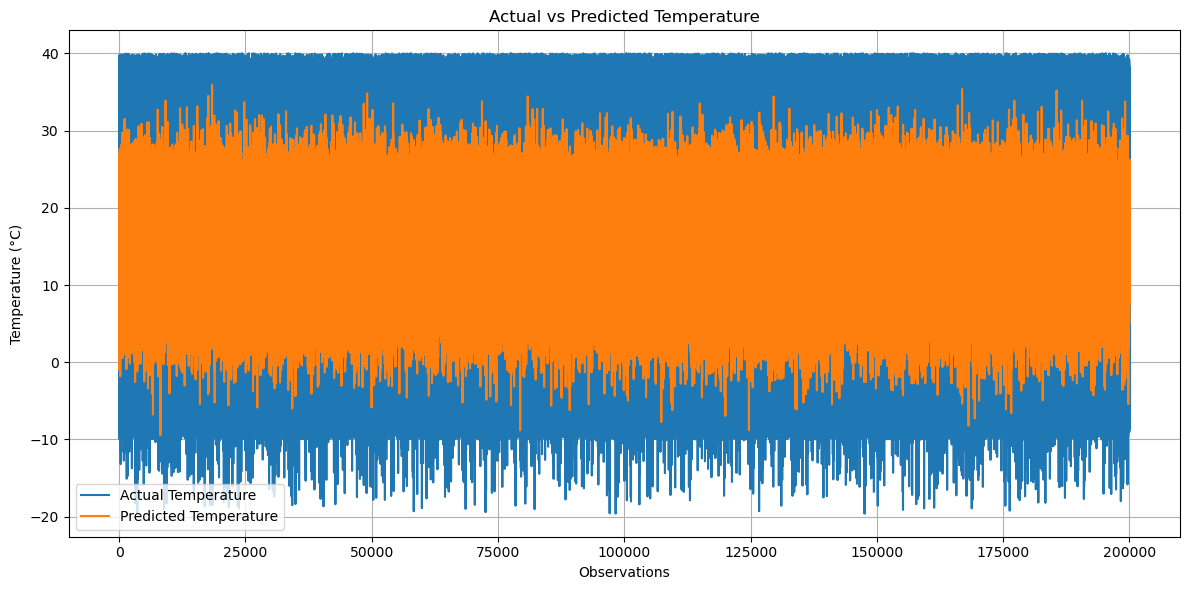


========== FEATURE IMPORTANCE ==========
            Feature  Importance
5  Precipitation_mm    0.254506
4      Humidity_pct    0.253293
6    Wind_Speed_kmh    0.252057
3               Day    0.130199
2             Month    0.055706
0     Location_Code    0.054240
1              Year    0.000000


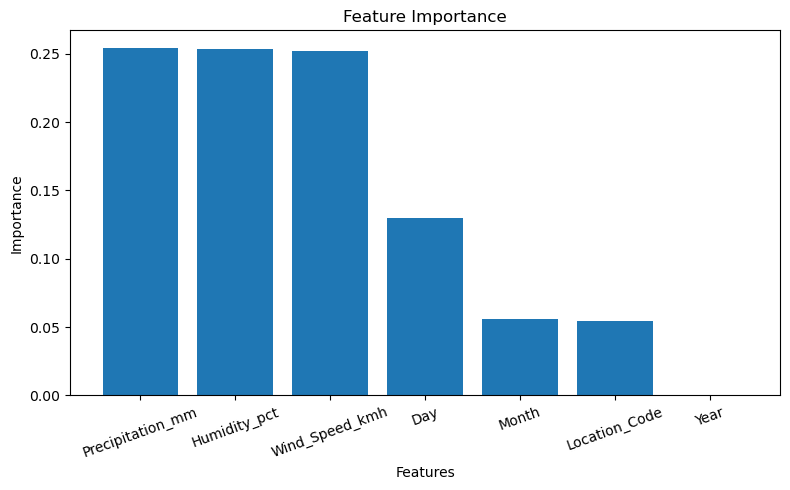


========== PROJECT COMPLETED SUCCESSFULLY ==========


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# =====================================
# 1. LOAD DATASET
# =====================================

df = pd.read_csv("weather_data.csv")

print("========== DATASET LOADED ==========")
print(df.head())
print("\nDataset Shape:", df.shape)

# =====================================
# 2. DATA CLEANING
# =====================================

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df['Date_Time'] = pd.to_datetime(df['Date_Time'])

df.sort_values('Date_Time', inplace=True)
df.reset_index(drop=True, inplace=True)

print("\n========== DATA CLEANED ==========")
print("Remaining Rows:", len(df))

# =====================================
# 3. FEATURE ENGINEERING
# =====================================

encoder = LabelEncoder()
df['Location_Code'] = encoder.fit_transform(df['Location'])

df['Year'] = df['Date_Time'].dt.year
df['Month'] = df['Date_Time'].dt.month
df['Day'] = df['Date_Time'].dt.day

print("\n========== FEATURE ENGINEERING COMPLETED ==========")

# =====================================
# 4. FEATURES & TARGET
# =====================================

X = df[
    [
        'Location_Code',
        'Year',
        'Month',
        'Day',
        'Humidity_pct',
        'Precipitation_mm',
        'Wind_Speed_kmh'
    ]
]

y = df['Temperature_C']

# =====================================
# 5. TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# =====================================
# 6. RANDOM FOREST MODEL
# =====================================

print("\nTraining Random Forest Model...")

model = RandomForestRegressor(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =====================================
# 7. PREDICTIONS
# =====================================

predictions = model.predict(X_test)

# =====================================
# 8. MODEL EVALUATION
# =====================================

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("\n========== MODEL RESULTS ==========")
print("R² Score:", round(r2, 4))
print("Model Score:", round(r2 * 100, 2), "%")
print("Mean Absolute Error:", round(mae, 2), "°C")

# =====================================
# 9. FUTURE TEMPERATURE PREDICTION
# =====================================

future_input = pd.DataFrame({
    'Location_Code': [df['Location_Code'].mode()[0]],
    'Year': [2025],
    'Month': [12],
    'Day': [31],
    'Humidity_pct': [df['Humidity_pct'].mean()],
    'Precipitation_mm': [df['Precipitation_mm'].mean()],
    'Wind_Speed_kmh': [df['Wind_Speed_kmh'].mean()]
})

future_temp = model.predict(future_input)

print("\n========== FUTURE PREDICTION ==========")
print("Predicted Temperature:", round(future_temp[0], 2), "°C")

# =====================================
# 10. GRAPH - TEMPERATURE TREND
# =====================================

plt.figure(figsize=(12,6))

plt.plot(
    df['Date_Time'],
    df['Temperature_C']
)

plt.title("Historical Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.tight_layout()
plt.show()

# =====================================
# 11. GRAPH - ACTUAL VS PREDICTED
# =====================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.reset_index(drop=True, inplace=True)

plt.figure(figsize=(12,6))

plt.plot(
    comparison['Actual'],
    label='Actual Temperature'
)

plt.plot(
    comparison['Predicted'],
    label='Predicted Temperature'
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Observations")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# =====================================
# 12. FEATURE IMPORTANCE
# =====================================

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")
print(importance_df)

plt.figure(figsize=(8,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

print("\n========== PROJECT COMPLETED SUCCESSFULLY ==========")